# YOTO pipeline: preprocess, Zuna, Labram 4-way comparison

## 1. Config and paths

In [1]:
import os
import subprocess
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "configs").exists() else Path.cwd().parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

DATA_ROOT = ROOT / "data"
RAW_ROOT = DATA_ROOT / "raw_samples"
MANIFESTS = DATA_ROOT / "manifests"
RUNS = ROOT / "runs"
YOTO_SUBJECTS = 5
DATASET_ID = "ds005815"

## 2. Download YOTO (5 subjects, task-task + rest1)

In [2]:
subprocess.run([sys.executable, "scripts/download_sample_subjects.py", "--yoto-five", "--skip-other"], cwd=ROOT, check=True)

#maybe do not download rest data but only event data next time

Found 5 subjects in ds005815
['sub-01', 'sub-02', 'sub-05', 'sub-07', 'sub-08']

👋 Hello! This is openneuro-py 2026.3.0. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/hoechenberger/openneuro-py/issues

🌍 Preparing to download ds005815 …


📁 Traversing directories for ds005815 : 0 entities [00:00, ? entities/s]/home/alex/miniconda3/envs/identify/lib/python3.14/multiprocessing/resource_tracker.py:396: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown: {'/mp-zadmutav'}
  warnings.warn(


KeyboardInterrupt: 

## 3. Build unified manifest

In [ ]:
subprocess.run([sys.executable, "scripts/build_unified_manifest.py"], cwd=ROOT, check=True)

## 4. YOTO preprocessing + event-based epoching (C/D/E tones)

In [ ]:
subprocess.run([sys.executable, "scripts/preprocess_yoto.py", "--skip-asr", "--skip-ica"], cwd=ROOT, check=True)

## 5. (Optional) Download derivatives if available

In [ ]:
# If ds005815 has derivatives on OpenNeuro, download and build derivatives index here.
# Otherwise skip; raw preprocessed = our pipeline output.

## 6. Export preprocessed to FIF for Zuna

In [ ]:
subprocess.run([sys.executable, "scripts/export_yoto_to_fif.py", "--skip-asr", "--skip-ica"], cwd=ROOT, check=True)

## 7. Run Zuna augmentation

In [ ]:
ZUNA_WORK = RUNS / "zuna_yoto"
ZUNA_WORK.mkdir(parents=True, exist_ok=True)
TEST_SUBJECT_ID = ""  # e.g. "sub-01" for a quick single-subject test
zuna_cmd = [
    sys.executable, "scripts/run_zuna_augmentation.py",
    "--input-fif-dir", str(ROOT / "data/processed/fif_for_zuna"),
    "--work-dir", str(ZUNA_WORK),
    "--diffusion-steps", "8",
]
if TEST_SUBJECT_ID:
    zuna_cmd += ["--subject-id", TEST_SUBJECT_ID]
subprocess.run(zuna_cmd, cwd=ROOT, check=True)


Processing Summary
  Total input files: 6
  Successful: 6
  Failed: 0
  Total epochs processed: 1798
  Total PT files saved: 30
  Output directory: /home/alex/identify/runs/zuna_yoto/2_pt_input


Signal handler installed.
[W305 15:26:40.870107458 ProcessGroupNCCL.cpp:929] Warning: TORCH_NCCL_AVOID_RECORD_STREAMS is the default now, this environment variable is thus deprecated. (function operator())
/home/alex/miniconda3/envs/identify/lib/python3.14/site-packages/torch/distributed/device_mesh.py:275: UserWarning: It seems like you did not set/select the default device for the current process before the DeviceMesh initialization or use a launcher (i.e. torchrun) which populates `LOCAL_RANK` environment variable. It is recommended to set the current device for the process BEFORE the DeviceMesh initialization so that the underlying communicator (i.e. NCCL) can be initialized properly. Given that the current process has no default device selected, DeviceMesh will use a heuristic to set the device_id via `global_rank % num_devices_per_host`, assuming homogeneous hardware cluster. 
  self._setup_world_group_and_device()
/home/alex/miniconda3/envs/identify/lib/python3.14/site-packages/

KeyboardInterrupt: 

/home/alex/miniconda3/envs/identify/lib/python3.14/multiprocessing/resource_tracker.py:396: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown: {'/mp-mzb0utoi'}
  warnings.warn(


## 8. Build Zuna-augmented long-format index

In [12]:
subprocess.run([
    sys.executable, "scripts/build_zuna_augmented_index_yoto.py",
    "--zuna-fif-dir", str(ZUNA_WORK / "4_fif_output"),
], cwd=ROOT, check=True)

Wrote 173 rows to /home/alex/identify/data/manifests/epoch_index_yoto_tones_zuna.csv


CompletedProcess(args=['/home/alex/miniconda3/envs/identify/bin/python', 'scripts/build_zuna_augmented_index_yoto.py', '--zuna-fif-dir', '/home/alex/identify/runs/zuna_yoto/4_fif_output'], returncode=0)

## 9. Train Labram (4 variants)

In [13]:
index_raw = MANIFESTS / "epoch_index_yoto_tones.csv"
index_zuna = MANIFESTS / "epoch_index_yoto_tones_zuna.csv"
index_derivatives = MANIFESTS / "epoch_index.csv"
index_derivatives_zuna = MANIFESTS / "epoch_index_with_zuna.csv"

for name, index, out in [
    ("raw", index_raw, RUNS / "labram_metrics_raw.json"),
    ("raw_zuna", index_zuna, RUNS / "labram_metrics_raw_zuna.json"),
    ("derivatives", index_derivatives, RUNS / "labram_metrics_derivatives.json"),
    ("derivatives_zuna", index_derivatives_zuna, RUNS / "labram_metrics_derivatives_zuna.json"),
]:
    if not index.exists():
        print(f"Skip {name}: {index} not found")
        continue
    subprocess.run([
        sys.executable, "scripts/train_labram.py",
        "--epoch-index", str(index),
        "--out-metrics", str(out),
        "--epochs", "5", "--batch-size", "16",
    ], cwd=ROOT, check=True)

/home/alex/miniconda3/envs/identify/lib/python3.14/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/alex/miniconda3/envs/identify/lib/python3.14/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Saved Labram metrics to /home/alex/identify/runs/labram_metrics_raw.json


/home/alex/miniconda3/envs/identify/lib/python3.14/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/alex/miniconda3/envs/identify/lib/python3.14/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Saved Labram metrics to /home/alex/identify/runs/labram_metrics_raw_zuna.json


## 10. Comparison

In [3]:
subprocess.run([sys.executable, "scripts/compare_labram_runs.py", "--plot"], cwd=ROOT, check=True)

Pipeline	Accuracy	N_train	N_test
raw	0.5000	104	98
raw_zuna	0.5000	77	96
derivatives	0.1246	1300	313
derivatives_zuna	0.0000	1339	291
Saved /home/alex/identify/runs/labram_comparison.png


CompletedProcess(args=['/home/alex/miniconda3/envs/identify/bin/python', 'scripts/compare_labram_runs.py', '--plot'], returncode=0)

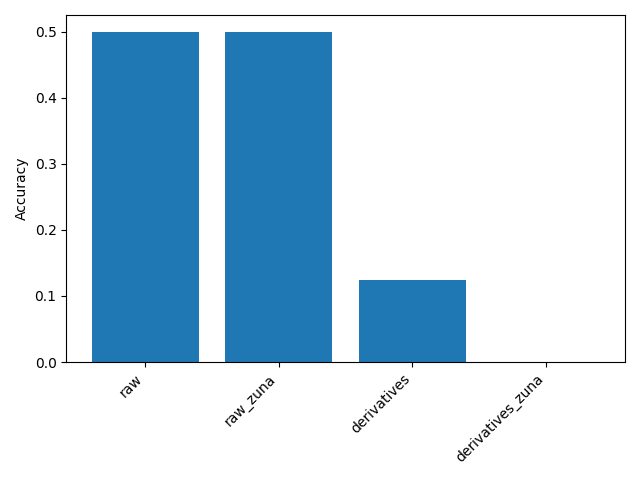

In [4]:
from IPython.display import Image, display

plot_path = RUNS / "labram_comparison.png"
if not plot_path.exists():
    subprocess.run([sys.executable, "scripts/compare_labram_runs.py", "--plot"], cwd=ROOT, check=True)

display(Image(filename=str(plot_path)))

In [7]:
# Run Streamlit dashboard
import subprocess

subprocess.run(["streamlit", "run", "dashboard/app.py"])





  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://10.103.16.80:8501
  External URL: http://58.60.1.29:8501



2026-03-07 15:30:20.084 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-07 15:30:20.104 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-07 15:30:20.122 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-07 15:30:20.150 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-07 15:30:20.158 

────────────────────────── Traceback (most recent call last) ───────────────────────────
  /home/alex/miniconda3/envs/identify/lib/python3.14/site-packages/streamlit/runtime/s  
  criptrunner/exec_code.py:129 in exec_func_with_error_handling                         
                                                                                        
  /home/alex/miniconda3/envs/identify/lib/python3.14/site-packages/streamlit/runtime/s  
  criptrunner/script_runner.py:689 in code_to_exec                                      
                                                                                        
  /home/alex/identify/dashboard/app.py:431 in <module>                                  
                                                                                        
    428                                                                                 
    429                                                                                 
    430 if __name__ =

2026-03-07 15:30:24.187 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-07 15:30:24.211 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-07 15:30:24.231 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-07 15:30:24.256 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-07 15:30:24.263 

────────────────────────── Traceback (most recent call last) ───────────────────────────
  /home/alex/miniconda3/envs/identify/lib/python3.14/site-packages/streamlit/runtime/s  
  criptrunner/exec_code.py:129 in exec_func_with_error_handling                         
                                                                                        
  /home/alex/miniconda3/envs/identify/lib/python3.14/site-packages/streamlit/runtime/s  
  criptrunner/script_runner.py:689 in code_to_exec                                      
                                                                                        
  /home/alex/identify/dashboard/app.py:431 in <module>                                  
                                                                                        
    428                                                                                 
    429                                                                                 
    430 if __name__ =

...

2026-03-07 15:32:23.299 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-07 15:32:23.319 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-07 15:32:23.343 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-07 15:32:23.351 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-07 15:32:23.352 

────────────────────────── Traceback (most recent call last) ───────────────────────────
  /home/alex/miniconda3/envs/identify/lib/python3.14/site-packages/streamlit/runtime/s  
  criptrunner/exec_code.py:129 in exec_func_with_error_handling                         
                                                                                        
  /home/alex/miniconda3/envs/identify/lib/python3.14/site-packages/streamlit/runtime/s  
  criptrunner/script_runner.py:689 in code_to_exec                                      
                                                                                        
  /home/alex/identify/dashboard/app.py:431 in <module>                                  
                                                                                        
    428                                                                                 
    429                                                                                 
    430 if __name__ =

2026-03-07 15:32:27.905 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-07 15:32:27.925 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-07 15:32:27.949 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-07 15:32:27.957 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-03-07 15:32:27.959 

────────────────────────── Traceback (most recent call last) ───────────────────────────
  /home/alex/miniconda3/envs/identify/lib/python3.14/site-packages/streamlit/runtime/s  
  criptrunner/exec_code.py:129 in exec_func_with_error_handling                         
                                                                                        
  /home/alex/miniconda3/envs/identify/lib/python3.14/site-packages/streamlit/runtime/s  
  criptrunner/script_runner.py:689 in code_to_exec                                      
                                                                                        
  /home/alex/identify/dashboard/app.py:431 in <module>                                  
                                                                                        
    428                                                                                 
    429                                                                                 
    430 if __name__ =

KeyboardInterrupt: 